# Netflix Exploratory Data Analysis (EDA)

## Project Overview
This project performs Exploratory Data Analysis (EDA) on the Netflix Titles dataset to identify patterns, trends, and relationships within Netflix content.

The analysis explores how Netflix’s content library is structured and how it has evolved over time. It examines content distribution, production trends, country contributions, rating patterns, and genre popularity. Additional analyses investigate catalog growth and relationships between numerical variables.

The goal of this project is to gain insights into Netflix’s content ecosystem through data visualization and statistical exploration.

Key Analyses Performed:

- Distribution of Movies vs TV Shows
- Content release trends over time
- Top countries producing Netflix content
- Distribution of content ratings
- Movie duration patterns
- Most popular genres
- Movies vs TV Shows Trend Over Time
- Correlation Heatmap of numerical variables
- Netflix Catalog Growth Rate Analysis
- Top Directors on Netflix


## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Dataset
Netflix Titles Dataset containing information such as:
- Title
- Type (Movie / TV Show)
- Country
- Release Year
- Rating
- Duration
- Genre

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
# Load dataset
df = pd.read_csv(r"D:\DSML\netflix-eda-project\data\netflix_cleaned.csv")

# Display first rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset Overview

Before performing analysis, we examine the dataset structure, size, and summary statistics.

In [3]:
# Basic Dataset Exploration
df.shape

(8797, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8797 entries, 0 to 8796
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8797 non-null   object
 1   type          8797 non-null   object
 2   title         8797 non-null   object
 3   director      8797 non-null   object
 4   cast          8797 non-null   object
 5   country       8797 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8797 non-null   int64 
 8   rating        8797 non-null   object
 9   duration      8797 non-null   object
 10  listed_in     8797 non-null   object
 11  description   8797 non-null   object
dtypes: int64(1), object(11)
memory usage: 824.8+ KB


In [5]:
df.describe()

,release_year
count,8797.000000
mean,2014.183472
std,8.822191
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 1. Content Type Analysis

This analysis explores whether Netflix contains more Movies or TV Shows.

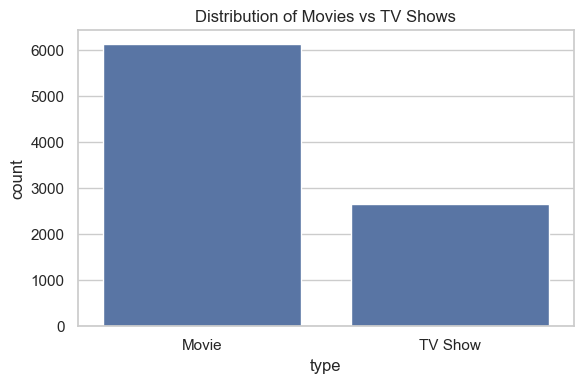

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.tight_layout()
plt.savefig("D:/DSML/netflix-eda-project/images/movies_vs_tvshows.png",
            dpi=300, bbox_inches='tight')
plt.show()

### Insight

Movies dominate Netflix content compared to TV Shows.
This indicates Netflix historically focused more on movie distribution.

## 2. Content Release Over Time

This analysis shows how Netflix content production has changed over the years.

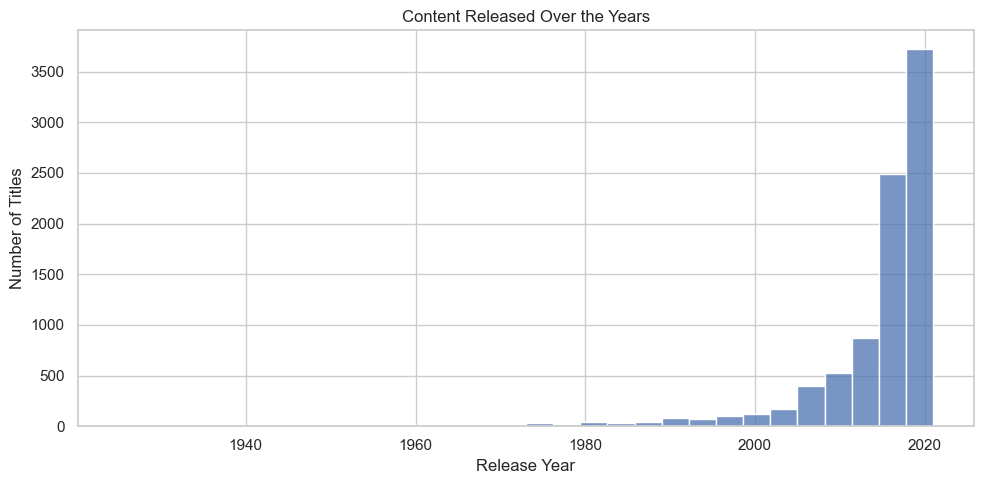

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30)
plt.title("Content Released Over the Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/release_year_trend.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

Content production increased significantly after 2015.
This reflects Netflix's global expansion and focus on producing original content.

## 3. Top Countries Producing Netflix Content

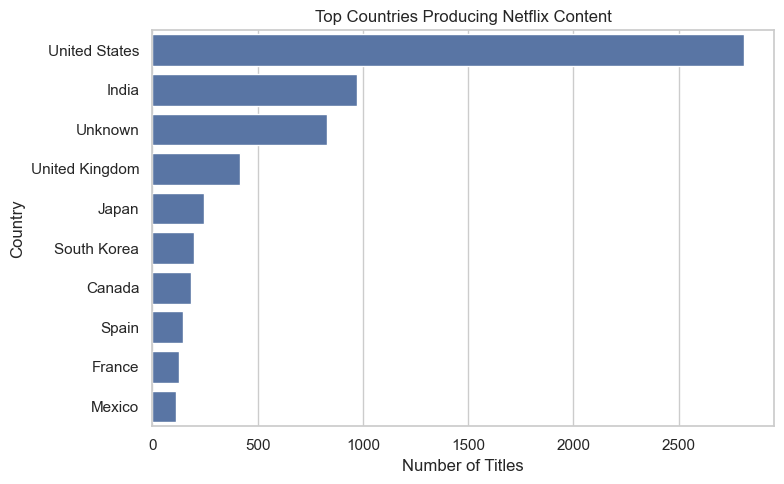

In [9]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("D:/DSML/netflix-eda-project/images/top_10_countries.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

The United States produces the highest number of Netflix titles.
India and the United Kingdom also contribute significantly.

## 4. Distribution of Content Ratings

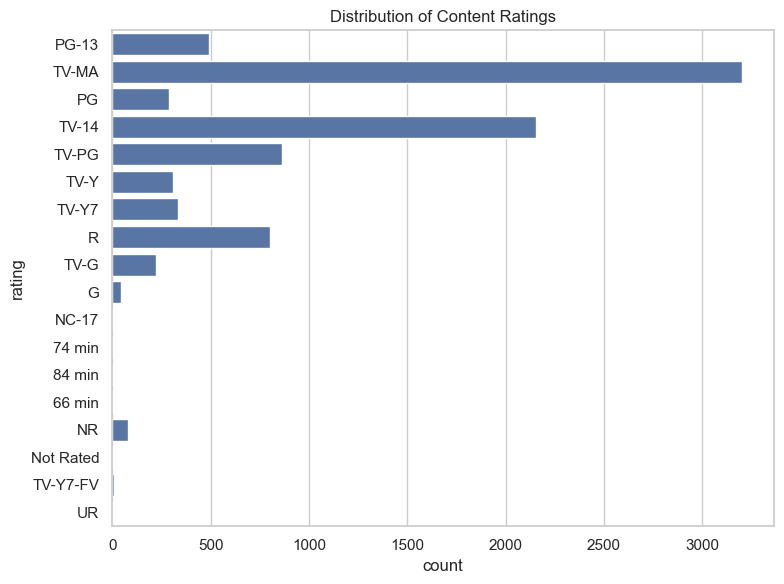

In [10]:
plt.figure(figsize=(8,6))
sns.countplot(y='rating', data=df)
plt.title("Distribution of Content Ratings")
plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/rating_distribution.png",
            dpi=300, bbox_inches='tight')
plt.show()

## Insight:
TV-MA and TV-14 dominate Netflix content ratings.

## 5. Movie Duration Analysis

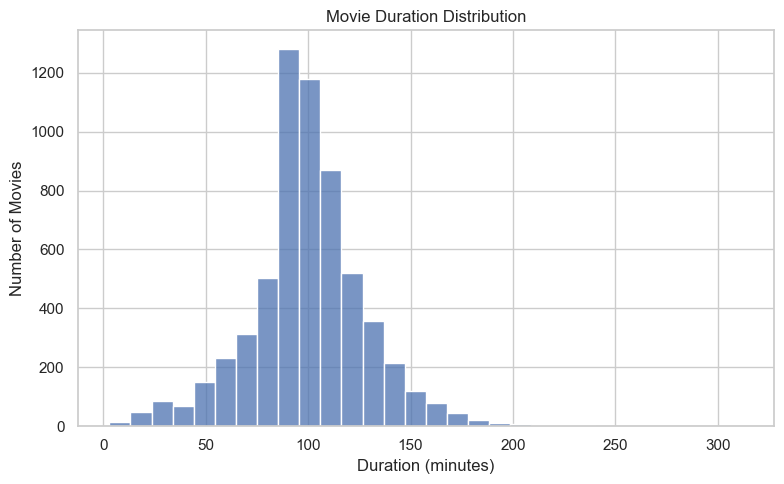

In [11]:
# Filter only movies
df_movies = df[df['type'] == "Movie"].copy()

# Remove ' min' text
df_movies['duration'] = df_movies['duration'].str.replace(' min', '', regex=False)

# Convert to numeric
df_movies['duration'] = pd.to_numeric(df_movies['duration'], errors='coerce')

# Plot histogram
plt.figure(figsize=(8,5))
sns.histplot(df_movies['duration'], bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("D:/DSML/netflix-eda-project/images/movie_duration_distribution.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

Most Netflix movies fall between 80 and 120 minutes.
This reflects the typical runtime of feature-length films.

## 6. Most Popular Genres on Netflix

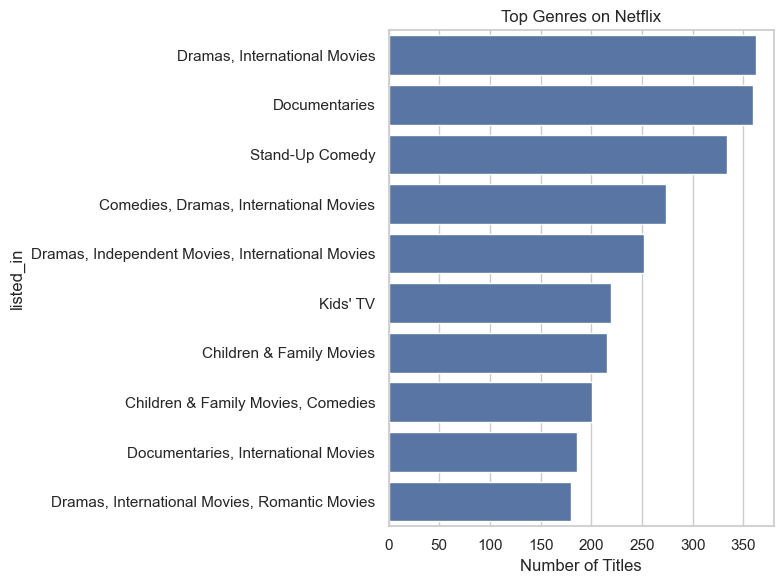

In [12]:
top_genres = df['listed_in'].value_counts().head(10)
plt.figure(figsize=(8,6))

sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top Genres on Netflix")
plt.xlabel("Number of Titles")

plt.tight_layout()
plt.savefig("D:/DSML/netflix-eda-project/images/top_genres.png",
            dpi=300, bbox_inches='tight')
plt.show()

## 7. Movies vs TV Shows Released Over Time

This analysis compares the number of Movies and TV Shows released each year on Netflix.
It helps identify trends in Netflix’s content strategy over time.

<Figure size 1200x600 with 0 Axes>

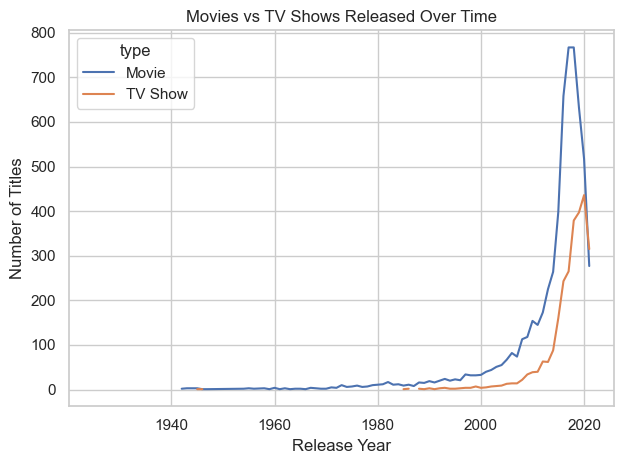

In [13]:
# Count movies and TV shows by release year

content_trend = df.groupby(['release_year','type']).size().unstack()

# Plot

plt.figure(figsize=(12,6))

content_trend.plot(kind='line')

plt.title("Movies vs TV Shows Released Over Time")

plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/movies_vs_tvshows_trend.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

Both Movies and TV Shows increased significantly after 2015.

However, Movies still dominate Netflix content overall, although TV Shows have been growing steadily in recent years as Netflix invests more in series-based content.

## 8. Correlation Analysis

To understand relationships between numeric variables in the dataset,
we analyze correlations between features such as:

- Release Year
- Movie Duration

This helps identify patterns in Netflix content characteristics.

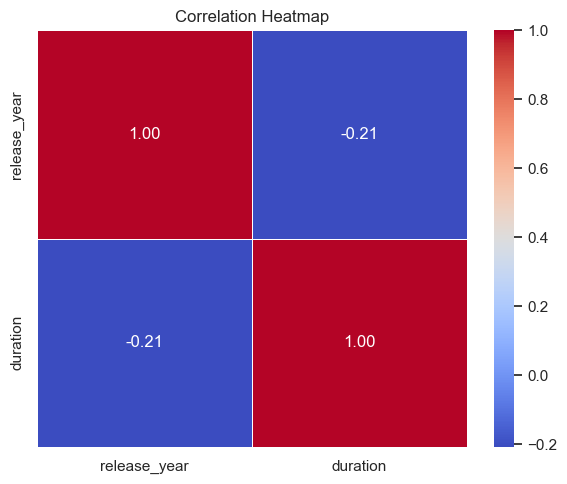

In [14]:
# Create numeric dataset

df_corr = df_movies[['release_year','duration']].copy()

# Compute correlation

corr_matrix = df_corr.corr()

# Plot heatmap

plt.figure(figsize=(6,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/correlation_heatmap.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

The correlation between release year and movie duration is weak (-0.21), indicating only a slight negative relationship.

This suggests that movie durations have not changed dramatically over time. Although newer movies may be slightly shorter on average, the overall variation in movie length remains relatively stable.

## 9. Netflix Catalog Growth Rate Analysis

Understanding how Netflix’s content library has grown over time provides insight into the platform’s expansion strategy. 

In this section, we analyze the **year-to-year growth rate of titles added to Netflix**. Instead of using the content release year, we use the **year when titles were added to Netflix (`date_added`)**, which better reflects the growth of the Netflix catalog.

By calculating the **percentage change in the number of titles added each year**, we can observe periods of rapid expansion and identify how Netflix scaled its content library over time.

In [15]:
# Netflix Catalog Growth Rate Analysis (data preparation)

# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract year when content was added to Netflix
df['year_added'] = df['date_added'].dt.year

# Count number of titles added each year
titles_added = df['year_added'].value_counts().sort_index()

# Calculate year-to-year growth rate
growth_rate = titles_added.pct_change() * 100

# Remove early years with very small counts to reduce noise
growth_rate = growth_rate[growth_rate.index >= 2013]

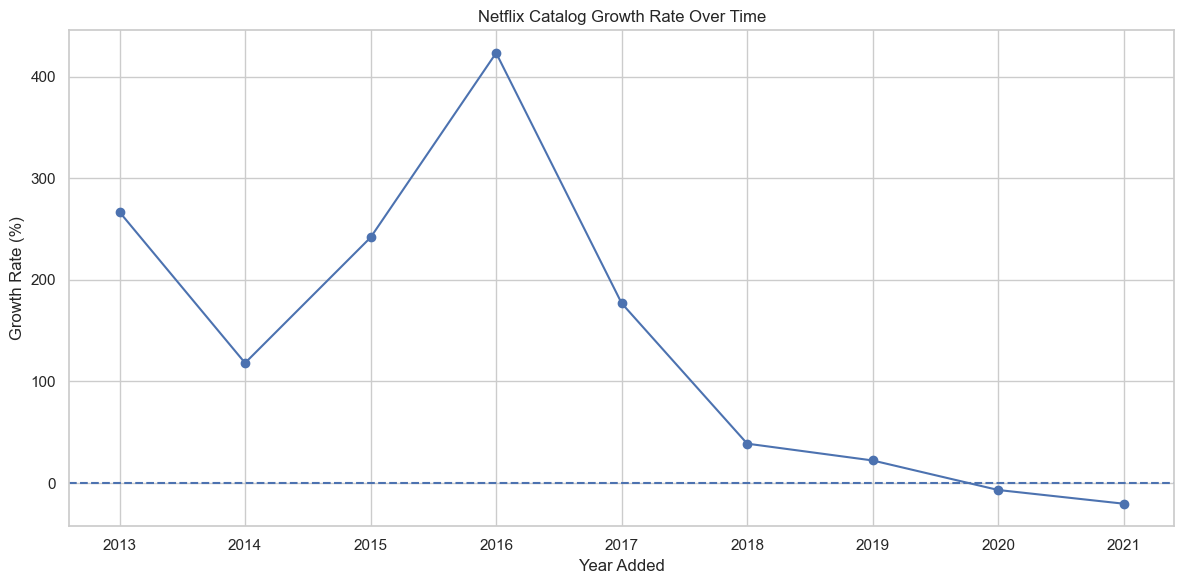

In [16]:
# Plot growth rate
plt.figure(figsize=(12,6))

plt.plot(growth_rate.index, growth_rate.values, marker='o')

plt.title("Netflix Catalog Growth Rate Over Time")

plt.xlabel("Year Added")
plt.ylabel("Growth Rate (%)")

plt.axhline(0, linestyle='--')

plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/content_growth_rate.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

Netflix’s content catalog experienced rapid expansion between 2013 and 2017 as the platform increased investment in original productions and global licensing.

After 2017, growth rates stabilized, indicating that Netflix had already built a large and mature content library.

## 10. Top 10 Directors on Netflix

This analysis identifies the directors who have contributed the most titles to Netflix.

Understanding the most frequent directors helps reveal which filmmakers have strong representation on the platform.

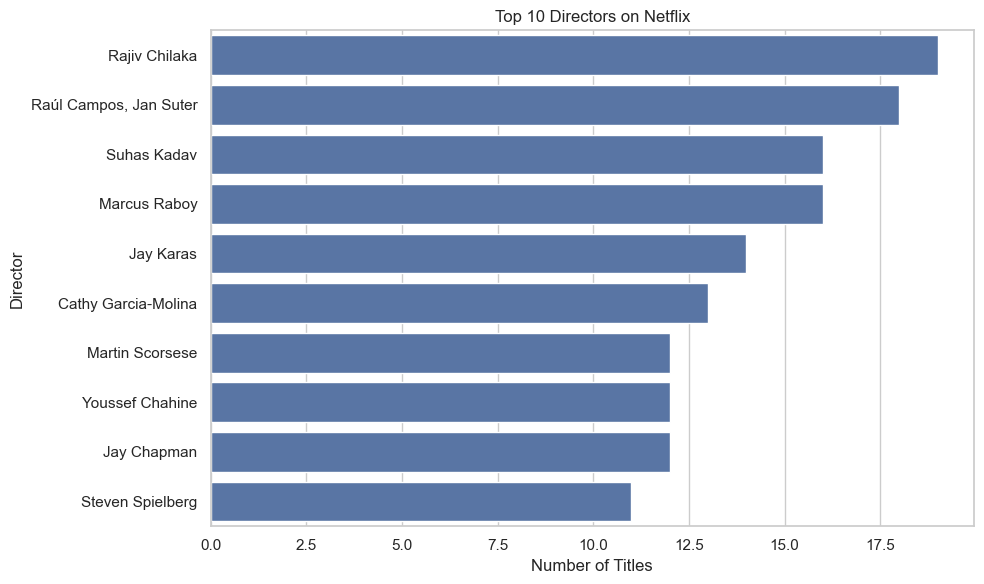

In [17]:
# Remove unknown directors

df_directors = df[df['director'] != 'Unknown']

# Count top directors

top_directors = df_directors['director'].value_counts().head(10)

# Plot

plt.figure(figsize=(10,6))

sns.barplot(x=top_directors.values, y=top_directors.index)

plt.title("Top 10 Directors on Netflix")

plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.tight_layout()

plt.savefig("D:/DSML/netflix-eda-project/images/top_directors.png",
            dpi=300, bbox_inches='tight')

plt.show()

### Insight

A small number of directors contribute multiple titles to Netflix.

This suggests that Netflix often collaborates repeatedly with certain filmmakers, particularly those producing successful or high-demand content.

# Final Key Findings

1. Movies dominate Netflix content compared to TV Shows.
2. Content production increased significantly after 2015.
3. The United States produces the highest number of Netflix titles, followed by countries such as India and the United Kingdom.
4. Most Netflix movies have a runtime between **80 and 120 minutes**.
5. **TV-MA and TV-14** are the most common content ratings, indicating that a large portion of Netflix content targets mature or teenage audiences.
6. **Drama and International Movies** are among the most common genres available on Netflix.
7. Both Movies and TV Shows increased rapidly after 2015.
8. Correlation analysis shows a **weak negative relationship (-0.21)** between release year and movie duration, suggesting that movie lengths have remained relatively **consistent** over time.
9. Netflix’s content catalog expanded rapidly between **2013 and 2017**, reflecting the platform’s global expansion and increased investment in original productions.
10. Certain directors have multiple titles on Netflix, indicating recurring collaborations.